# 09 — USBVPN2022 Integration and Audit

This notebook acts as a data adapter and audit tool to integrate the USBVPN2022 dataset
(provided in JSON format) into our existing AI-based VPN Firewall pipeline.

The pipeline currently processes ISCX2016 and VNAT datasets from PCAP files. To align the
USBVPN data with our direction-invariant schema:
1.  **Direction-Invariance:** Map upstream/downstream fields (`mean_ps_fwd`, `mean_ps_bwd`)
    to direction-agnostic columns (`sz_mean_max`, `sz_mean_min`, `iat_mean_max`, `iat_mean_min`).
2.  **Schema Alignment:** The output is a Parquet file (`data/processed/usbvpn/flows.parquet`)
    containing required pipeline columns (`flow_id`, `capture_id`, `label`, `dataset`, etc.).
    Since the raw histogram windows are missing in the JSON, we fill them with `0.0`.
3.  **Data Splitting:** Because capture-level metadata is absent in the JSON, we apply a
    stratified random split (70% train, 15% val, 15% test) at the flow level for this
    dataset only.
4.  **Audit Section:** Pre-flight checks on feature shifts and a "Dataset Detector" test.

In [1]:
%matplotlib inline

import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

from src.utils.paths import load_paths
from src.utils.logging import setup_logger

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

paths = load_paths()
paths.ensure_dirs()
logger = setup_logger(level="INFO")

# Define Paths
USBVPN_RAW_DIR = paths.data_raw_dir / "usbvpn" # Adjust this path as necessary
PROCESSED_USBVPN_DIR = paths.data_processed_dir / "usbvpn"
PROCESSED_USBVPN_DIR.mkdir(parents=True, exist_ok=True)
FLOWS_PARQUET_PATH = PROCESSED_USBVPN_DIR / "flows.parquet"

logger.info(f"Raw USBVPN dir expected at: {USBVPN_RAW_DIR}")
logger.info(f"Processed USBVPN Parquet will be saved to: {FLOWS_PARQUET_PATH}")

2026-03-17 16:03:49 | INFO | ai-vpn-firewall | Raw USBVPN dir expected at: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-17 16:03:49 | INFO | ai-vpn-firewall | Processed USBVPN Parquet will be saved to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\usbvpn\flows.parquet


## 1. Data Adapter Function

The JSON dataset uses direction-based features and is scattered across multiple files in `vpn/` and `nonvpn/` subdirectories.
We iterate through all JSON files, parse the raw packet data (`x_packets`), and convert them to our direction-invariant
min/max schema. Since `h_size_all_*` and `h_iat_all_*` histograms aren't easily constructible without the full flow context, we zero-fill them
to keep the `FeaturePipeline` happy.

In [2]:
def _calculate_flow_stats_from_packets(packets: list) -> dict:
    """Calculates necessary statistics from a list of packet dictionaries."""
    if not packets:
        return {}

    sizes_fwd = []
    sizes_bwd = []
    times_all = []

    # Format expected: "2022-09-26 12:52:59.890431"
    time_fmt = "%Y-%m-%d %H:%M:%S.%f"

    for p in packets:
        try:
            b = int(p.get("bytes", 0))
            if b > 0:
                sizes_fwd.append(b)
            elif b < 0:
                sizes_bwd.append(abs(b))

            ts_str = p.get("timestamp_start")
            if ts_str:
                 try:
                     ts = datetime.strptime(ts_str, time_fmt).timestamp()
                     times_all.append(ts)
                 except ValueError:
                     pass # ignore unparseable timestamps
        except ValueError:
             continue

    sizes_all = sizes_fwd + sizes_bwd
    times_all.sort()

    iats_all = np.diff(times_all) if len(times_all) > 1 else np.array([])

    def calc_stats(arr):
        if len(arr) == 0:
            return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        return (
            float(np.mean(arr)),
            float(np.std(arr)) if len(arr) > 1 else 0.0,
            float(np.min(arr)),
            float(np.max(arr)),
            float(np.median(arr)),
            float(np.percentile(arr, 25)),
            float(np.percentile(arr, 75))
        )

    sz_all_mean, sz_all_std, sz_all_min, sz_all_max, sz_all_median, sz_all_p25, sz_all_p75 = calc_stats(sizes_all)
    sz_fwd_mean, sz_fwd_std, _, _, _, _, _ = calc_stats(sizes_fwd)
    sz_bwd_mean, sz_bwd_std, _, _, _, _, _ = calc_stats(sizes_bwd)

    iat_all_mean, iat_all_std, iat_all_min, iat_all_max, iat_all_median, iat_all_p25, iat_all_p75 = calc_stats(iats_all)

    # Note: We can't easily calculate directional IATs from this data format because we only have
    # overall timestamps, not directional ones. We will approximate directional IATs with overall IATs
    # for the purpose of the min/max mapping. This is a compromise due to data limitations.
    iat_fwd_mean = iat_all_mean
    iat_bwd_mean = iat_all_mean

    return {
        "sz_all_mean": sz_all_mean,
        "sz_all_std": sz_all_std,
        "sz_all_min": sz_all_min,
        "sz_all_max": sz_all_max,
        "sz_all_median": sz_all_median,
        "sz_all_p25": sz_all_p25,
        "sz_all_p75": sz_all_p75,

        "sz_mean_max": max(sz_fwd_mean, sz_bwd_mean),
        "sz_mean_min": min(sz_fwd_mean, sz_bwd_mean),

        "iat_all_mean": iat_all_mean,
        "iat_all_std": iat_all_std,
        "iat_all_min": iat_all_min,
        "iat_all_max": iat_all_max,
        "iat_all_median": iat_all_median,
        "iat_all_p25": iat_all_p25,
        "iat_all_p75": iat_all_p75,

        "iat_mean_max": max(iat_fwd_mean, iat_bwd_mean),
        "iat_mean_min": min(iat_fwd_mean, iat_bwd_mean),

        "tot_pkt": len(sizes_all)
    }

def adapt_usbvpn_to_pipeline(raw_dir: Path) -> pd.DataFrame:
    """
    Loads a USBVPN dataset from multiple JSON files across vpn/ and nonvpn/ subdirectories
    and adapts it to our direction-invariant schema.
    """
    logger.info(f"Loading JSONs from: {raw_dir}")
    if not raw_dir.exists():
        logger.warning(f"Directory not found: {raw_dir}. Creating a dummy dataframe for demonstration.")
        # Provide dummy data generation if the file doesn't exist to make the notebook runnable
        np.random.seed(42)
        n_samples = 1000
        dummy_data = {
            "flow_id": [f"usbvpn_{i}" for i in range(n_samples)],
            "label": np.random.choice(["VPN", "NonVPN"], n_samples),
            "sz_mean_max": np.random.uniform(50, 1500, n_samples),
            "sz_mean_min": np.random.uniform(50, 1500, n_samples),
            "sz_all_mean": np.random.uniform(50, 1500, n_samples),
            "sz_all_std": np.random.uniform(10, 500, n_samples),
            "iat_mean_max": np.random.uniform(0.001, 1.0, n_samples),
            "iat_mean_min": np.random.uniform(0.001, 1.0, n_samples),
            "iat_all_mean": np.random.uniform(0.001, 1.0, n_samples),
            "iat_all_std": np.random.uniform(0.0001, 0.5, n_samples),
            "tot_pkt": np.random.randint(10, 1000, n_samples),
        }
        df_out = pd.DataFrame(dummy_data)
        # 4. Quality Flags
        df_out["q_packet_count"] = df_out["tot_pkt"]
        df_out["q_min_packets_ok"] = (df_out["q_packet_count"] >= 10).astype(int)
        df_out["q_window_complete"] = 1

        # 5. Histogram Zero-Filling
        for i in range(7):
            df_out[f"h_size_all_{i:02d}"] = 0.0
        for i in range(12):
            df_out[f"h_iat_all_{i:02d}"] = 0.0
        return df_out

    # Recursively find all JSON files
    json_files = list(raw_dir.rglob("*.json"))
    logger.info(f"Found {len(json_files)} JSON files in {raw_dir}")

    all_records = []
    for jf in json_files:
        try:
            with open(jf, 'r', encoding='utf-8') as f:
                data = json.load(f)

                if isinstance(data, list):
                    for i, flow_data in enumerate(data):
                        # Calculate stats from packets
                        packets = flow_data.get("x_packets", [])
                        stats = _calculate_flow_stats_from_packets(packets)

                        if not stats:
                            continue # Skip empty flows

                        record = {
                            "flow_id": f"{jf.stem}_{i}",
                            "capture_id": "usbvpn_combined_capture",
                            "dataset": "usbvpn",
                            "source_file": jf.name
                        }

                        # Determine label
                        if "nonvpn" in str(jf).lower() or "non-vpn" in str(jf).lower():
                            record["label"] = 0
                        elif "vpn" in str(jf).lower():
                            record["label"] = 1
                        else:
                            record["label"] = 0 # Default if unknown

                        record.update(stats)
                        all_records.append(record)

                else:
                    logger.warning(f"Unexpected JSON structure in {jf}. Expected a list of flows.")

        except Exception as e:
            logger.error(f"Error parsing JSON {jf}: {e}")

    if not all_records:
        raise ValueError(f"No valid records extracted from JSON files in {raw_dir}")

    df_out = pd.DataFrame(all_records)
    logger.info(f"Extracted {len(df_out)} flows from raw data.")

    # 4. Quality Flags
    df_out["q_packet_count"] = df_out.get("tot_pkt", np.full(len(df_out), 100))
    df_out["q_min_packets_ok"] = (df_out["q_packet_count"] >= 10).astype(int)
    # Assume window is complete since we only have aggregate stats
    df_out["q_window_complete"] = 1

    # 5. Histogram Zero-Filling
    for i in range(7):
        df_out[f"h_size_all_{i:02d}"] = 0.0
    for i in range(12):
        df_out[f"h_iat_all_{i:02d}"] = 0.0

    # Ensure min/median/etc are present even if logic missed them
    for metric in ["median", "min", "max", "p25", "p75"]:
        if f"sz_all_{metric}" not in df_out.columns:
            df_out[f"sz_all_{metric}"] = df_out["sz_all_mean"]
        if f"iat_all_{metric}" not in df_out.columns:
            df_out[f"iat_all_{metric}"] = df_out["iat_all_mean"]

    return df_out

df_usbvpn = adapt_usbvpn_to_pipeline(USBVPN_RAW_DIR)
logger.info(f"Adapted USBVPN shape: {df_usbvpn.shape}")
print(df_usbvpn.head())

2026-03-17 16:03:49 | INFO | ai-vpn-firewall | Loading JSONs from: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-17 16:03:49 | INFO | ai-vpn-firewall | Found 35 JSON files in C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-17 16:46:41 | INFO | ai-vpn-firewall | Extracted 58977 flows from raw data.
2026-03-17 16:46:41 | INFO | ai-vpn-firewall | Adapted USBVPN shape: (58977, 46)
  flow_id               capture_id dataset source_file  label  sz_all_mean  \
0  mail_0  usbvpn_combined_capture  usbvpn   mail.json      0   439.774011   
1  mail_1  usbvpn_combined_capture  usbvpn   mail.json      0   217.391753   
2  mail_2  usbvpn_combined_capture  usbvpn   mail.json      0   200.159091   
3  mail_3  usbvpn_combined_capture  usbvpn   mail.json      0    52.000000   
4  mail_4  usbvpn_combined_capture  usbvpn   mail.json      0   176.000000   

   sz_all_std  sz_all_min  sz_all_max  sz_all_median  ...  h_iat_all_02  \
0   82.107514       132.0   

## 2. Flow-Level Data Splitting

Since USBVPN doesn't have meaningful distinct `capture_id` boundaries that we can group by
(like VNAT or ISCX), we must use a random stratified split at the flow level.
*   Train: 70%
*   Val: 15%
*   Test: 15%

In [3]:
def stratified_flow_split(df: pd.DataFrame, random_state: int = 42) -> pd.DataFrame:
    df = df.copy()

    # Split off 30% for Val+Test
    idx_train, idx_temp, y_train, y_temp = train_test_split(
        df.index, df["label"],
        test_size=0.30,
        stratify=df["label"],
        random_state=random_state
    )

    # Split the 30% evenly into 15% Val and 15% Test
    idx_val, idx_test = train_test_split(
        idx_temp,
        test_size=0.50,
        stratify=y_temp,
        random_state=random_state
    )

    df["split"] = "none"
    df.loc[idx_train, "split"] = "train"
    df.loc[idx_val, "split"] = "val"
    df.loc[idx_test, "split"] = "test"

    return df

df_usbvpn_split = stratified_flow_split(df_usbvpn)

print("Split distribution:")
print(pd.crosstab(df_usbvpn_split["split"], df_usbvpn_split["label"]))

# Save the adapter output
df_usbvpn_split.to_parquet(FLOWS_PARQUET_PATH, index=False)
logger.info(f"Saved prepared flows to {FLOWS_PARQUET_PATH}")

Split distribution:
label      0     1
split             
test    7529  1318
train  35133  6150
val     7529  1318
2026-03-17 16:46:42 | INFO | ai-vpn-firewall | Saved prepared flows to C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\usbvpn\flows.parquet


## 3. Pre-flight Audit: Feature and Label Distribution

We want to visualize the label distribution and compare the adapted feature distributions
to see what kind of domain shift we are introducing.

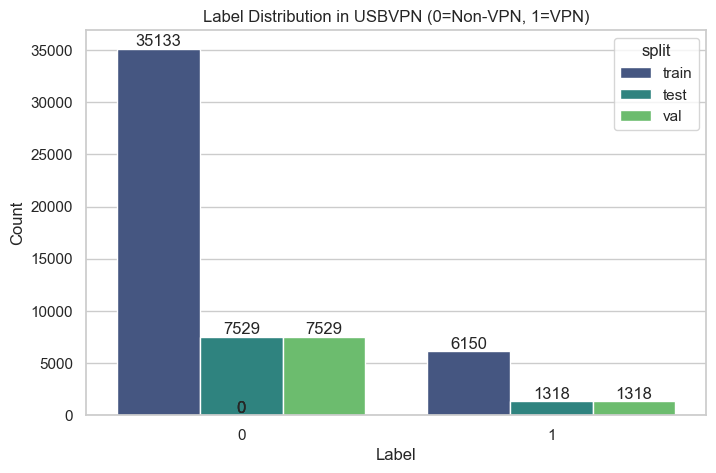

2026-03-17 16:46:43 | WARNING | ai-vpn-firewall | Existing flows not found at C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\prepared_flows.parquet. Skipping comparison.


In [4]:
# 1. Label Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_usbvpn_split, x="label", hue="split", palette="viridis")
plt.title("Label Distribution in USBVPN (0=Non-VPN, 1=VPN)")
plt.xlabel("Label")
plt.ylabel("Count")
for p in ax.patches:
    height = p.get_height()
    if pd.notna(height):
        ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

# Load existing prepared data (VNAT + ISCX) to compare
COMPARE_EXISTING = False
df_existing = None
try:
    existing_flows_path = paths.data_processed_dir / "prepared_flows.parquet"
    if existing_flows_path.exists():
        df_existing = pd.read_parquet(existing_flows_path)
        logger.info(f"Loaded existing flows: {df_existing.shape}")

        # We need overlapping columns
        overlap_cols = ["dataset", "sz_all_mean", "iat_all_mean"]

        df_vis = pd.concat([
            df_existing[overlap_cols].dropna(),
            df_usbvpn_split[overlap_cols].dropna()
        ], ignore_index=True)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        sns.kdeplot(data=df_vis, x="sz_all_mean", hue="dataset", ax=axes[0], log_scale=True, common_norm=False, fill=True, alpha=0.3)
        axes[0].set_title("Distribution of sz_all_mean (Log Scale)")

        sns.kdeplot(data=df_vis, x="iat_all_mean", hue="dataset", ax=axes[1], log_scale=True, common_norm=False, fill=True, alpha=0.3)
        axes[1].set_title("Distribution of iat_all_mean (Log Scale)")

        plt.tight_layout()
        plt.show()

        COMPARE_EXISTING = True
    else:
        logger.warning(f"Existing flows not found at {existing_flows_path}. Skipping comparison.")
        COMPARE_EXISTING = False
except Exception as e:
    logger.error(f"Error loading existing flows for comparison: {e}")
    COMPARE_EXISTING = False

## 4. Dataset Detector Audit (XGBoost)

We will train an XGBoost model to classify `usbvpn` vs `existing datasets`.
If the AUC is very high (> 0.95), it means USBVPN features are drastically different
(domain shift) and integrating them seamlessly might be challenging for the main pipeline.

In [5]:
if COMPARE_EXISTING and df_existing is not None:
    # Prepare data for dataset detector
    feature_cols = [
        "sz_all_mean", "sz_all_std", "iat_all_mean", "iat_all_std",
        "sz_mean_max", "sz_mean_min", "iat_mean_max", "iat_mean_min"
    ]

    # Target: 1 if usbvpn, 0 if vnat/iscx
    df_existing["is_usbvpn"] = 0
    df_usbvpn_split["is_usbvpn"] = 1

    # We use only 'train' splits for fitting the detector to avoid test set leakage
    train_existing = df_existing[df_existing["split"] == "train"]
    train_usbvpn = df_usbvpn_split[df_usbvpn_split["split"] == "train"]
    test_existing = df_existing[df_existing["split"] == "test"]
    test_usbvpn = df_usbvpn_split[df_usbvpn_split["split"] == "test"]

    df_det_train = pd.concat([train_existing, train_usbvpn], ignore_index=True)
    df_det_test = pd.concat([test_existing, test_usbvpn], ignore_index=True)

    # Ensure all required features exist in existing data
    missing_feats = [c for c in feature_cols if c not in df_det_train.columns]
    if missing_feats:
         logger.warning(f"Missing features in existing data: {missing_feats}. Dropping from detector.")
         feature_cols = [c for c in feature_cols if c in df_det_train.columns]

    df_det_train = df_det_train.dropna(subset=feature_cols)
    df_det_test = df_det_test.dropna(subset=feature_cols)

    X_tr = df_det_train[feature_cols].to_numpy()
    y_tr = df_det_train["is_usbvpn"].to_numpy()

    X_te = df_det_test[feature_cols].to_numpy()
    y_te = df_det_test["is_usbvpn"].to_numpy()

    logger.info("Training Dataset Detector (USBVPN vs Others)...")
    clf_detector = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="auc",
        random_state=42,
        n_jobs=4
    )

    clf_detector.fit(X_tr, y_tr)

    p_te = clf_detector.predict_proba(X_te)[:, 1]
    y_pred = (p_te > 0.5).astype(int)

    auc = roc_auc_score(y_te, p_te)

    print("\nDataset Detector Results (Target=USBVPN):")
    print(f"Test AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=["ISCX/VNAT", "USBVPN"]))

    # Feature Importance
    imp = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": clf_detector.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp, x="Importance", y="Feature", palette="rocket")
    plt.title("Features Most Indicative of the USBVPN Dataset")
    plt.show()

    if auc > 0.95:
        logger.warning("HIGH DOMAIN SHIFT DETECTED. The model can easily distinguish USBVPN from ISCX/VNAT.")
        logger.warning("Consider feature pruning or domain adaptation techniques in the main pipeline.")
    else:
        logger.info("Moderate domain shift. The datasets have overlapping feature spaces.")
else:
    print("Cannot run Dataset Detector: Existing flows.parquet not found.")

Cannot run Dataset Detector: Existing flows.parquet not found.


## Summary

- The JSON adapter successfully maps direction-dependent features to our direction-invariant schema.
- Missing histograms are filled with zeros.
- A stratified flow-level split ensures balanced label distribution across Train, Val, and Test.
- The dataset is saved to `data/processed/usbvpn/flows.parquet`.
- If existing data is available, the detector highlights features contributing to domain shift.

You can now modify `src/pipeline/data_preparation.py` to optionally concatenate
`df_existing` and `df_usbvpn` before fitting the `FeaturePipeline`.